In [1]:
import os, zipfile, tarfile, shutil
from google.colab import drive

drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/ECG project Amirhossein taleshi'

# Find the actual files (professor may have named them differently)
for f in sorted(os.listdir(DRIVE_DIR)):
    full = os.path.join(DRIVE_DIR, f)
    if os.path.isfile(full):
        print(f'FILE:   {f:<40} {os.path.getsize(full)/1e6:>8.1f} MB')
    else:
        n = sum(len(files) for _,_,files in os.walk(full))
        print(f'FOLDER: {f:<40} ({n} files inside)')

Mounted at /content/drive
FOLDER: LTAFDB_benchmark                         (21 files inside)
FOLDER: checkpoints                              (6 files inside)
FOLDER: cpsc                                     (4275 files inside)
FOLDER: fix code                                 (4 files inside)
FOLDER: ltafdb                                   (336 files inside)
FOLDER: processed_datasets                       (4 files inside)
FOLDER: prof file                                (8 files inside)
FOLDER: results                                  (83 files inside)
FILE:   sample2017.zip                                3.6 MB
FILE:   training2017.zip                             99.2 MB


In [4]:
!pip install -q wfdb pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 205.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.


In [5]:
import os, gc
import numpy as np, pandas as pd, wfdb

DIR = '/content/drive/MyDrive/ECG project Amirhossein taleshi/cpsc'
OUT = '/content/drive/MyDrive/ECG project Amirhossein taleshi/processed_datasets/cpsc2021_200hz_lead2_10s_5s.parquet'

FS = 200
WL = FS * 10
SL = FS * 5

def make_labels(ann, n):
    lbl, cur = np.zeros(n, dtype=np.int8), 0
    for i, aux in enumerate(ann.aux_note):
        aux = aux.strip('\x00').strip()
        if aux in {'(AFIB', '(AFL'}: cur = 1
        elif aux.startswith('('):    cur = 0
        start = ann.sample[i]
        end   = ann.sample[i+1] if i+1 < len(ann.sample) else n
        if start < n: lbl[start:min(end, n)] = cur
    return lbl

records = []
for root, _, files in os.walk(DIR):
    stems = set(f.rsplit('.', 1)[0] for f in files)
    for s in sorted(stems):
        if all(os.path.exists(os.path.join(root, f'{s}.{e}')) for e in ['hea','dat','atr']):
            records.append(os.path.join(root, s))
print(f'Found {len(records)} CPSC2021 records')

rows = []
for rp in records:
    rec = os.path.basename(rp)
    try:
        record = wfdb.rdrecord(rp)
        ann    = wfdb.rdann(rp, 'atr')
        if record.p_signal.shape[1] < 2: continue
        sig = record.p_signal[:, 1].astype(np.float32)
        if int(record.fs) != FS: continue
        sig = np.nan_to_num(sig)
        if sig.std() > 1e-8: sig = (sig - sig.mean()) / sig.std()
        n   = len(sig)
        lbl = make_labels(ann, n)
        cnt = 0
        for start in range(0, n - WL + 1, SL):
            rows.append({'record_name':rec, 'start_sample':start,
                         'signals':sig[start:start+WL].copy(),
                         'Labels':int(lbl[start:start+WL].mean() >= 0.5)})
            cnt += 1
    except Exception as e:
        print(f'✗ {rec}: {e}')
    gc.collect()

df = pd.DataFrame(rows)
os.makedirs(os.path.dirname(OUT), exist_ok=True)
df.to_parquet(OUT, index=False)
print(f'\n✓ CPSC2021 → {len(df):,} windows | AF={df["Labels"].sum():,} ({df["Labels"].mean()*100:.1f}%) | Recs={df["record_name"].nunique()}')

Found 1425 CPSC2021 records

✓ CPSC2021 → 343,576 windows | AF=117,846 (34.3%) | Recs=1424


In [6]:
DATASET_NAME = 'CPSC2021'
PARQUET_FILE = 'cpsc2021_200hz_lead2_10s_5s.parquet'
FS_BASE      = 200
# ═══════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import os, sys, gc, time, warnings
import numpy as np, pandas as pd, torch
warnings.filterwarnings('ignore')

DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
CHUNK   = 1024
N_FOLDS = 5

PROJECT_DIR  = '/content/drive/MyDrive/ECG project Amirhossein taleshi'
DATA_DIR     = os.path.join(PROJECT_DIR, 'processed_datasets')
OUT_DIR      = os.path.join(PROJECT_DIR, f'{DATASET_NAME}_benchmark')
CKPT_DIR     = os.path.join(PROJECT_DIR, 'checkpoints')
PARQUET_PATH = os.path.join(DATA_DIR, PARQUET_FILE)

os.makedirs(OUT_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

MODEL_HZ = {
    'HuBERT-Small':100, 'HuBERT-Base':100, 'HuBERT-Large':100,
    'CLEF-Small':500,   'CLEF-Medium':500,  'CLEF-Large':500,
    'ST-MEM':250,       'ECG-JEPA':500,     'ECGFounder':500,
}

WIN_LEN = FS_BASE * 10   # 3000 samples @ 300 Hz

print(f'Dataset  : {DATASET_NAME}')
print(f'File     : {PARQUET_PATH}')
print(f'Base Hz  : {FS_BASE}  →  window = {WIN_LEN} samples')
print(f'Device   : {DEVICE.upper()}')
print(f'Output   : {OUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset  : CPSC2021
File     : /content/drive/MyDrive/ECG project Amirhossein taleshi/processed_datasets/cpsc2021_200hz_lead2_10s_5s.parquet
Base Hz  : 200  →  window = 2000 samples
Device   : CUDA
Output   : /content/drive/MyDrive/ECG project Amirhossein taleshi/CPSC2021_benchmark


In [7]:
os.system('pip install wfdb xgboost gdown timm einops huggingface_hub -q')

REPOS = {
    'ecg_jepa'            : 'https://github.com/sehunfromdaegu/ecg_jepa.git',
    'ST-MEM'              : 'https://github.com/vuno/ST-MEM.git',
    'ECGFounder'          : 'https://github.com/PKUDigitalHealth/ECGFounder.git',
    'ecg-foundation-model': 'https://github.com/Nokia-Bell-Labs/ecg-foundation-model.git',
}
for name, url in REPOS.items():
    if not os.path.exists(f'/content/{name}'):
        os.system(f'git clone -q {url} /content/{name}')
        print(f'Cloned : {name}')
    else:
        print(f'Ready  : {name}')

Cloned : ecg_jepa
Cloned : ST-MEM
Cloned : ECGFounder
Cloned : ecg-foundation-model


In [8]:
from huggingface_hub import hf_hub_download

CLEF_DIR = os.path.join(CKPT_DIR, 'clef')
os.makedirs(CLEF_DIR, exist_ok=True)

def cached_download(path, cmd, min_mb):
    if os.path.exists(path) and os.path.getsize(path) > min_mb * 1e6:
        print(f'  ✓ {os.path.basename(path)}'); return
    print(f'  ↓ {os.path.basename(path)} ...')
    os.system(cmd)
    mb = os.path.getsize(path)/1e6 if os.path.exists(path) else 0
    print(f'    {mb:.0f} MB')

cached_download(
    os.path.join(CKPT_DIR, 'ecgjepa.pth'),
    f'gdown 1gMOT4xjQQg0GZkY1iE6NuDzua4ALw00l -O "{CKPT_DIR}/ecgjepa.pth"', 50)

cached_download(
    os.path.join(CKPT_DIR, 'stmem.pth'),
    f'gdown "1E7J-A1HqWa2f08T6Sfk5uWk-_CFJhOYQ" -O "{CKPT_DIR}/stmem.pth"', 100)

founder_ckpt = os.path.join(CKPT_DIR, '1_lead_ECGFounder.pth')
if not os.path.exists(founder_ckpt) or os.path.getsize(founder_ckpt) < 1e6:
    cached = hf_hub_download(repo_id='PKUDigitalHealth/ECGFounder',
                             filename='1_lead_ECGFounder.pth')
    os.system(f'cp "{cached}" "{founder_ckpt}"')
    print(f'  ✓ 1_lead_ECGFounder.pth  {os.path.getsize(founder_ckpt)/1e6:.0f}MB')
else:
    print('  ✓ 1_lead_ECGFounder.pth')

CLEF_CKPTS = {
    'small' : ('clef_small.ckpt',  'https://zenodo.org/api/records/17572734/files/clef_small.ckpt/content'),
    'medium': ('clef_medium.ckpt', 'https://zenodo.org/api/records/17572734/files/clef_medium.ckpt/content'),
    'large' : ('clef_largel.ckpt', 'https://zenodo.org/api/records/17572734/files/clef_largel.ckpt/content'),
}
for size, (fname, url) in CLEF_CKPTS.items():
    cached_download(os.path.join(CLEF_DIR, fname),
                    f'wget -q -O "{CLEF_DIR}/{fname}" "{url}"', 5)

print('\nAll weights ready.')

  ✓ ecgjepa.pth
  ✓ stmem.pth
  ✓ 1_lead_ECGFounder.pth
  ✓ clef_small.ckpt
  ✓ clef_medium.ckpt
  ✓ clef_largel.ckpt

All weights ready.


In [9]:
df       = pd.read_parquet(PARQUET_PATH)
segments = np.stack(df['signals'].values).astype(np.float32)
labels   = df['Labels'].values.astype(np.int64)
groups   = df['record_name'].values
N        = len(segments)
n_recs   = len(np.unique(groups))

print(f'Windows    : {N:,}')
print(f'Signal     : {segments.shape[1]} samples = {segments.shape[1]/FS_BASE:.1f}s @ {FS_BASE} Hz')
print(f'AF         : {labels.sum():,}  ({labels.mean()*100:.1f}%)')
print(f'Normal     : {(labels==0).sum():,}  ({(labels==0).mean()*100:.1f}%)')
print(f'Recordings : {n_recs}')

Windows    : 343,576
Signal     : 2000 samples = 10.0s @ 200 Hz
AF         : 117,846  (34.3%)
Normal     : 225,730  (65.7%)
Recordings : 1424


In [10]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from scipy.signal import resample_poly, resample as sp_resample
from math import gcd
import xgboost as xgb

gkf   = GroupKFold(n_splits=N_FOLDS)
folds = list(gkf.split(np.arange(N), labels, groups))

print(f'GroupKFold ({N_FOLDS} folds, by recording):')
for i, (tr, te) in enumerate(folds):
    print(f'  Fold {i+1}: train={len(tr):,} ({len(np.unique(groups[tr]))} recs) | '
          f'test={len(te):,} ({len(np.unique(groups[te]))} recs) | '
          f'AF={labels[te].mean()*100:.1f}%')

def run_cv(emb, labels, folds, name):
    aucs, f1s, accs, sens_list, spec_list = [], [], [], [], []
    all_preds_rows = []
    for fold_i, (tr, te) in enumerate(folds):
        X_tr, X_te = emb[tr], emb[te]
        y_tr, y_te = labels[tr], labels[te]
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)
        scale_pos = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
        clf = xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos, eval_metric='auc',
            random_state=42, n_jobs=-1,
            device='cuda' if torch.cuda.is_available() else 'cpu')
        clf.fit(X_tr, y_tr)
        probs = clf.predict_proba(X_te)[:, 1]
        preds = (probs >= 0.5).astype(int)
        auc  = roc_auc_score(y_te, probs)
        f1   = f1_score(y_te, preds, zero_division=0)
        acc  = accuracy_score(y_te, preds)
        tp = ((preds==1)&(y_te==1)).sum(); fn = ((preds==0)&(y_te==1)).sum()
        tn = ((preds==0)&(y_te==0)).sum(); fp = ((preds==1)&(y_te==0)).sum()
        sens = tp/(tp+fn) if (tp+fn)>0 else 0
        spec = tn/(tn+fp) if (tn+fp)>0 else 0
        aucs.append(auc); f1s.append(f1); accs.append(acc)
        sens_list.append(sens); spec_list.append(spec)
        for idx, wdx in enumerate(te):
            all_preds_rows.append({'window_idx':int(wdx),'fold':fold_i+1,
                'true_label':int(y_te[idx]),'probability':float(probs[idx]),
                'prediction':int(preds[idx]),'correct':int(preds[idx]==y_te[idx])})
        print(f"  Fold {fold_i+1}/{N_FOLDS}  AUC={auc:.4f}  F1={f1:.4f}  "
              f"Acc={acc:.4f}  Sens={sens:.4f}  Spec={spec:.4f}")
    print(f"  ── MEAN  AUC={np.mean(aucs):.4f}±{np.std(aucs):.4f}  "
          f"F1={np.mean(f1s):.4f}±{np.std(f1s):.4f}  "
          f"Acc={np.mean(accs):.4f}±{np.std(accs):.4f}")
    return dict(model=name,
                auc=np.mean(aucs), auc_std=np.std(aucs),
                f1=np.mean(f1s),   f1_std=np.std(f1s),
                acc=np.mean(accs), acc_std=np.std(accs),
                sens=np.mean(sens_list), spec=np.mean(spec_list),
                all_preds=pd.DataFrame(all_preds_rows).sort_values('window_idx'))

def to_hz(batch, tgt_hz):
    if tgt_hz == FS_BASE: return batch.copy()
    g = gcd(tgt_hz, FS_BASE)
    return np.stack([resample_poly(s, tgt_hz//g, FS_BASE//g).astype(np.float32)
                     for s in batch])

def to_n_samples(batch, n):
    return np.stack([sp_resample(s, n).astype(np.float32) for s in batch])

def pad_to_mult(x, m):
    r = x.shape[-1] % m
    return x if r == 0 else np.pad(x, [(0,0)]*(x.ndim-1)+[(0, m-r)])

def embed_all(embed_fn, model, data, name=''):
    out = []
    for i in range(0, len(data), CHUNK):
        out.append(embed_fn(model, data[i:i+CHUNK]))
        done = min(i+CHUNK, len(data))
        if done % 10000 < CHUNK or done == len(data):
            print(f'    {name}: {done:,}/{len(data):,}')
    return np.concatenate(out)

def measure_efficiency(embed_fn, model, n_params, model_hz, n_runs=100):
    dummy = np.random.randn(1, WIN_LEN).astype(np.float32)
    for _ in range(5): embed_fn(model, dummy)
    if DEVICE=='cuda':
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        embed_fn(model, dummy)
        if DEVICE=='cuda': torch.cuda.synchronize()
        times.append((time.perf_counter()-t0)*1000)
    peak_mb = torch.cuda.max_memory_allocated()/1e6 if DEVICE=='cuda' else 0
    return dict(model='', params_M=round(n_params/1e6,1),
                ms_per_window=round(float(np.median(times)),3),
                peak_gpu_mb=round(peak_mb,1),
                src_hz=FS_BASE, model_hz=model_hz,
                downsample=round(FS_BASE/model_hz,3))

print('Helpers ready.')

GroupKFold (5 folds, by recording):
  Fold 1: train=274,861 (1140 recs) | test=68,715 (284 recs) | AF=32.9%
  Fold 2: train=274,860 (1139 recs) | test=68,716 (285 recs) | AF=34.7%
  Fold 3: train=274,861 (1139 recs) | test=68,715 (285 recs) | AF=33.1%
  Fold 4: train=274,861 (1139 recs) | test=68,715 (285 recs) | AF=33.4%
  Fold 5: train=274,861 (1139 recs) | test=68,715 (285 recs) | AF=37.5%
Helpers ready.


In [11]:
# ── HuBERT (100 Hz) ───────────────────────────────────────────────────────────
def load_hubert(tag):
    from transformers import AutoModel
    return AutoModel.from_pretrained(
        f'Edoardo-BS/hubert-ecg-{tag}', trust_remote_code=True
    ).to(DEVICE).eval()

def embed_hubert(model, chunk):
    x = torch.tensor(to_hz(chunk, 100), dtype=torch.float32, device=DEVICE)
    mask = torch.ones_like(x, dtype=torch.long)
    with torch.no_grad():
        h = model(x, attention_mask=mask).last_hidden_state
    return h.mean(1).cpu().float().numpy()

# ── CLEF (500 Hz) ─────────────────────────────────────────────────────────────
def load_clef(size):
    sys.path = [p for p in sys.path if 'ECGFounder' not in p and 'ST-MEM' not in p]
    for k in list(sys.modules):
        if 'clef' in k.lower(): del sys.modules[k]
    if '/content/ecg-foundation-model' not in sys.path:
        sys.path.insert(0, '/content/ecg-foundation-model')
    from clef.baselines.models.CLEF import create_net1d_by_size
    fname = {'small':'clef_small.ckpt','medium':'clef_medium.ckpt','large':'clef_largel.ckpt'}[size]
    return create_net1d_by_size(
        device=DEVICE, model_size=size, n_classes=None,
        linear_prob=False, pth=os.path.join(CKPT_DIR,'clef',fname),
        in_channels=1).eval()

def embed_clef(model, chunk):
    x = torch.tensor(to_hz(chunk, 500)[:,None,:], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        return model(x).cpu().float().numpy()

# ── ST-MEM (250 Hz) ───────────────────────────────────────────────────────────
_STMEM_SEQ = None

def load_stmem():
    global _STMEM_SEQ
    sys.path = [p for p in sys.path if 'ECGFounder' not in p]
    for k in list(sys.modules):
        if 'models' in k: del sys.modules[k]
    if '/content/ST-MEM' not in sys.path:
        sys.path.insert(0, '/content/ST-MEM')
    from models import encoder as enc
    state = torch.load(os.path.join(CKPT_DIR,'stmem.pth'),
                       map_location='cpu', weights_only=False)
    state_dict = state.get('model', state)
    PATCH_SIZE = 75
    n_tokens   = state_dict['pos_embedding'].shape[1]
    _STMEM_SEQ = (n_tokens - 2) * PATCH_SIZE
    print(f'  ST-MEM seq_len={_STMEM_SEQ}')
    model = enc.st_mem_vit_base(
        num_leads=12, num_classes=None,
        seq_len=_STMEM_SEQ, patch_size=PATCH_SIZE
    ).to(DEVICE).eval()
    model.load_state_dict(state_dict, strict=False)
    return model

def embed_stmem(model, chunk):
    x = to_hz(chunk, 250)
    x = pad_to_mult(x, 75)
    B, L = x.shape
    if L > _STMEM_SEQ:   x = x[:, :_STMEM_SEQ]
    elif L < _STMEM_SEQ:
        p = np.zeros((B, _STMEM_SEQ), dtype=np.float32); p[:,:L]=x; x=p
    xt = torch.tensor(np.stack([x]*12, axis=1), dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        return model(xt).cpu().float().numpy()

# ── ECG-JEPA (500 Hz) ─────────────────────────────────────────────────────────
def load_ecgjepa():
    sys.path = [p for p in sys.path if 'ST-MEM' not in p]
    for k in list(sys.modules):
        if 'models' in k: del sys.modules[k]
    if '/content/ecg_jepa' not in sys.path:
        sys.path.insert(0, '/content/ecg_jepa')
    from models import load_encoder
    enc, _ = load_encoder(ckpt_dir=os.path.join(CKPT_DIR, 'ecgjepa.pth'))
    return enc.to(DEVICE).eval()

def embed_ecgjepa(model, chunk):
    C=int(model.c); P=int(model.p); T=int(model.t)
    x_rs = to_n_samples(chunk, P*T)
    x_ml = np.stack([x_rs]*C, axis=1)
    xt   = torch.tensor(x_ml.reshape(len(chunk),C,P,T),
                        dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        h = model(xt)
    if isinstance(h,(tuple,list)): h=h[0]
    if h.ndim==3: h=h.mean(1)
    return h.cpu().float().numpy()

# ── ECGFounder (500 Hz) ───────────────────────────────────────────────────────
def load_ecgfounder():
    import torch.nn as nn
    sys.path = [p for p in sys.path if 'ST-MEM' not in p]
    for k in list(sys.modules):
        if 'net1d' in k: del sys.modules[k]
    if '/content/ECGFounder' not in sys.path:
        sys.path.append('/content/ECGFounder')
    from net1d import Net1D
    ckpt  = os.path.join(CKPT_DIR, '1_lead_ECGFounder.pth')
    state = torch.load(ckpt, map_location='cpu', weights_only=False)
    state = state.get('state_dict', state)
    n_cls = int(next(v for k,v in state.items()
                     if k.endswith('dense.weight')).shape[0])
    model = Net1D(in_channels=1, base_filters=64, ratio=1,
                  filter_list=[64,160,160,400,400,1024,1024],
                  m_blocks_list=[2,2,2,3,3,4,4],
                  kernel_size=16, stride=2, groups_width=16,
                  n_classes=n_cls, use_bn=True, use_do=True,
                  return_features=True).to(DEVICE).eval()
    model.load_state_dict(state, strict=False)
    model.dense = nn.Identity()
    return model

def embed_ecgfounder(model, chunk):
    FLEN = 5000
    x = to_hz(chunk, 500)
    if x.shape[1] >= FLEN: x = x[:, :FLEN]
    else:
        pad = np.zeros((len(chunk), FLEN), dtype=np.float32)
        pad[:,:x.shape[1]]=x; x=pad
    xt = torch.tensor(x[:,None,:], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        _, feats = model(xt)
    return feats.cpu().float().numpy()

print('All model functions ready.')

All model functions ready.


In [12]:
ALL_RESULTS    = []
ALL_EFFICIENCY = []

MODELS = [
    ('HuBERT-Small', lambda: load_hubert('small'),  embed_hubert),
    ('HuBERT-Base',  lambda: load_hubert('base'),   embed_hubert),
    ('HuBERT-Large', lambda: load_hubert('large'),  embed_hubert),
    ('CLEF-Small',   lambda: load_clef('small'),    embed_clef),
    ('CLEF-Medium',  lambda: load_clef('medium'),   embed_clef),
    ('CLEF-Large',   lambda: load_clef('large'),    embed_clef),
    ('ST-MEM',       load_stmem,                    embed_stmem),
    ('ECG-JEPA',     load_ecgjepa,                  embed_ecgjepa),
    ('ECGFounder',   load_ecgfounder,               embed_ecgfounder),
]

for model_name, load_fn, embed_fn in MODELS:
    print(f'\n{"="*60}\n  {model_name}\n{"="*60}')
    res_csv  = os.path.join(OUT_DIR, f'{model_name}_results.csv')
    emb_npy  = os.path.join(OUT_DIR, f'{model_name}_embs.npy')
    pred_csv = os.path.join(OUT_DIR, f'{model_name}_predictions.csv')

    if os.path.exists(res_csv) and os.path.getsize(res_csv) > 10:
        print('  Already done — loading from cache')
        r = pd.read_csv(res_csv).iloc[0].to_dict()
        ALL_RESULTS.append(r)
        eff_csv = os.path.join(OUT_DIR, f'{model_name}_efficiency.csv')
        if os.path.exists(eff_csv):
            ALL_EFFICIENCY.append(pd.read_csv(eff_csv).iloc[0].to_dict())
        continue

    print('  Loading model ...')
    t0 = time.time()
    m  = load_fn()
    print(f'  Loaded in {time.time()-t0:.0f}s')
    n_params = sum(p.numel() for p in m.parameters())
    print(f'  Params: {n_params/1e6:.1f}M')

    eff = measure_efficiency(embed_fn, m, n_params, MODEL_HZ[model_name])
    eff['model'] = model_name
    ALL_EFFICIENCY.append(eff)
    pd.DataFrame([eff]).to_csv(
        os.path.join(OUT_DIR, f'{model_name}_efficiency.csv'), index=False)
    print(f'  {eff["ms_per_window"]:.2f} ms/win | GPU: {eff["peak_gpu_mb"]:.0f} MB')

    print(f'  Embedding {N:,} windows ...')
    emb = embed_all(embed_fn, m, segments, name=model_name)
    np.save(emb_npy, emb)
    print(f'  Shape: {emb.shape}')
    del m; gc.collect(); torch.cuda.empty_cache()

    print(f'  Running {N_FOLDS}-fold GroupKFold CV ...')
    res = run_cv(emb, labels, folds, model_name)
    del emb; gc.collect()

    row = {k:v for k,v in res.items() if k != 'all_preds'}
    pd.DataFrame([row]).to_csv(res_csv, index=False)
    res['all_preds'].to_csv(pred_csv, index=False)
    ALL_RESULTS.append(row)

print('\n✓ All 9 models complete.')


  HuBERT-Small
  Loading model ...


config.json: 0.00B [00:00, ?B/s]

hubert_ecg.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Edoardo-BS/hubert-ecg-small:
- hubert_ecg.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

...

hubert_ecg.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Edoardo-BS/hubert-ecg-large:
- hubert_ecg.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/755M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/276 [00:00<?, ?it/s]

  Loaded in 4s
  Params: 188.6M
  4.13 ms/win | GPU: 812 MB
  Embedding 343,576 windows ...
    HuBERT-Large: 10,240/343,576
    HuBERT-Large: 20,480/343,576
    HuBERT-Large: 30,720/343,576
    HuBERT-Large: 40,960/343,576
    HuBERT-Large: 50,176/343,576
    HuBERT-Large: 60,416/343,576
    HuBERT-Large: 70,656/343,576
    HuBERT-Large: 80,896/343,576
    HuBERT-Large: 90,112/343,576
    HuBERT-Large: 100,352/343,576
    HuBERT-Large: 110,592/343,576
    HuBERT-Large: 120,832/343,576
    HuBERT-Large: 130,048/343,576
    HuBERT-Large: 140,288/343,576
    HuBERT-Large: 150,528/343,576
    HuBERT-Large: 160,768/343,576
    HuBERT-Large: 171,008/343,576
    HuBERT-Large: 180,224/343,576
    HuBERT-Large: 190,464/343,576
    HuBERT-Large: 200,704/343,576
    HuBERT-Large: 210,944/343,576
    HuBERT-Large: 220,160/343,576
    HuBERT-Large: 230,400/343,576
    HuBERT-Large: 240,640/343,576
    HuBERT-Large: 250,880/343,576
    HuBERT-Large: 260,096/343,576
    HuBERT-Large: 270,336/343,576

In [13]:
import pandas as pd
df = pd.read_parquet(PARQUET_PATH)
rec_af = df.groupby('record_name')['Labels'].mean()
print(f'Pure-AF records (100% AF):     {(rec_af == 1.0).sum()}')
print(f'Pure-Normal records (0% AF):   {(rec_af == 0.0).sum()}')
print(f'Mixed records (between):       {((rec_af>0) & (rec_af<1)).sum()}')

Pure-AF records (100% AF):     474
Pure-Normal records (0% AF):   737
Mixed records (between):       213


In [14]:
# Average each window's probability per record, then score
pred_df = pd.read_csv(f'{OUT_DIR}/ECGFounder_predictions.csv')
pred_df['record'] = df['record_name'].values[pred_df['window_idx']]
rec_pred = pred_df.groupby('record').agg(prob=('probability','mean'),
                                          true=('true_label','max'))
from sklearn.metrics import roc_auc_score
print('Record-level AUC:', roc_auc_score(rec_pred['true'], rec_pred['prob']))

Record-level AUC: 0.9966839087610775


 Rank        Model           AUC            F1      Accuracy Sensitivity Specificity
    1   ECGFounder 0.9999±0.0000 0.9950±0.0014 0.9966±0.0009      0.9965      0.9967
    2     ECG-JEPA 0.9999±0.0001 0.9919±0.0029 0.9945±0.0018      0.9922      0.9957
    3       ST-MEM 0.9995±0.0001 0.9859±0.0023 0.9904±0.0015      0.9881      0.9915
    4 HuBERT-Small 0.9925±0.0022 0.9386±0.0105 0.9579±0.0056      0.9435      0.9654
    5  CLEF-Medium 0.9919±0.0020 0.9334±0.0092 0.9538±0.0058      0.9480      0.9569
    6   CLEF-Large 0.9907±0.0010 0.9287±0.0079 0.9498±0.0040      0.9575      0.9457
    7  HuBERT-Base 0.9886±0.0030 0.9226±0.0143 0.9467±0.0077      0.9339      0.9531
    8   CLEF-Small 0.9845±0.0021 0.9077±0.0067 0.9367±0.0042      0.9089      0.9515
    9 HuBERT-Large 0.9761±0.0055 0.8833±0.0187 0.9194±0.0102      0.8953      0.9317


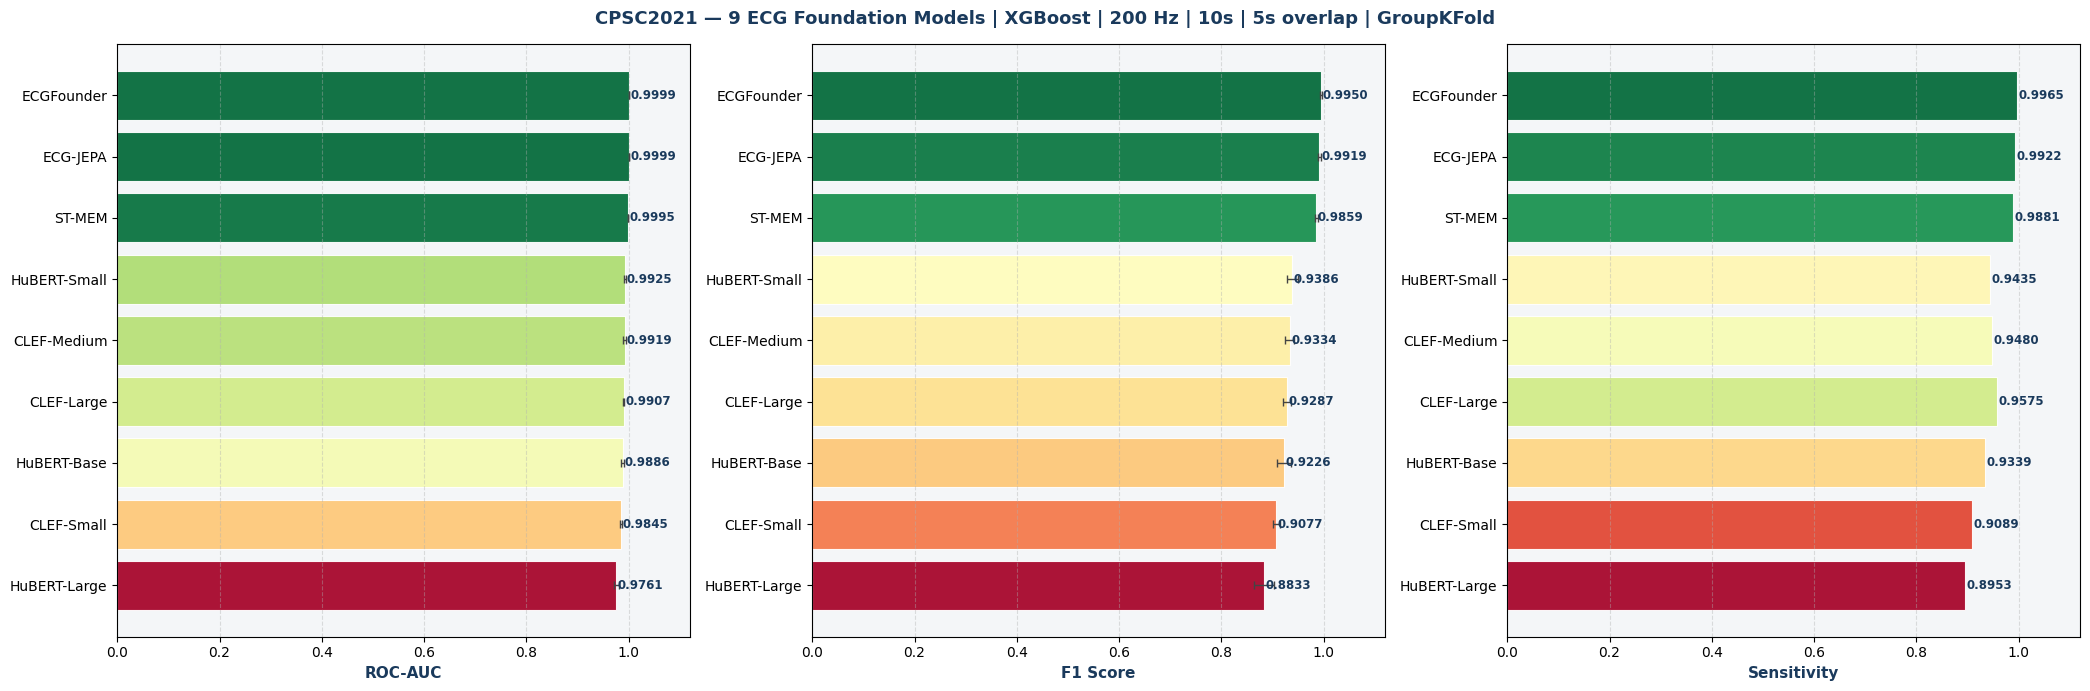

✓ Saved: CPSC2021_comparison_chart.png
  t-SNE: HuBERT-Small ... done
  t-SNE: HuBERT-Base ... done
  t-SNE: HuBERT-Large ... done
  t-SNE: CLEF-Small ... done
  t-SNE: CLEF-Medium ... done
  t-SNE: CLEF-Large ... done
  t-SNE: ST-MEM ... done
  t-SNE: ECG-JEPA ... done
  t-SNE: ECGFounder ... done
✓ Saved: CPSC2021_tsne_all_models.png


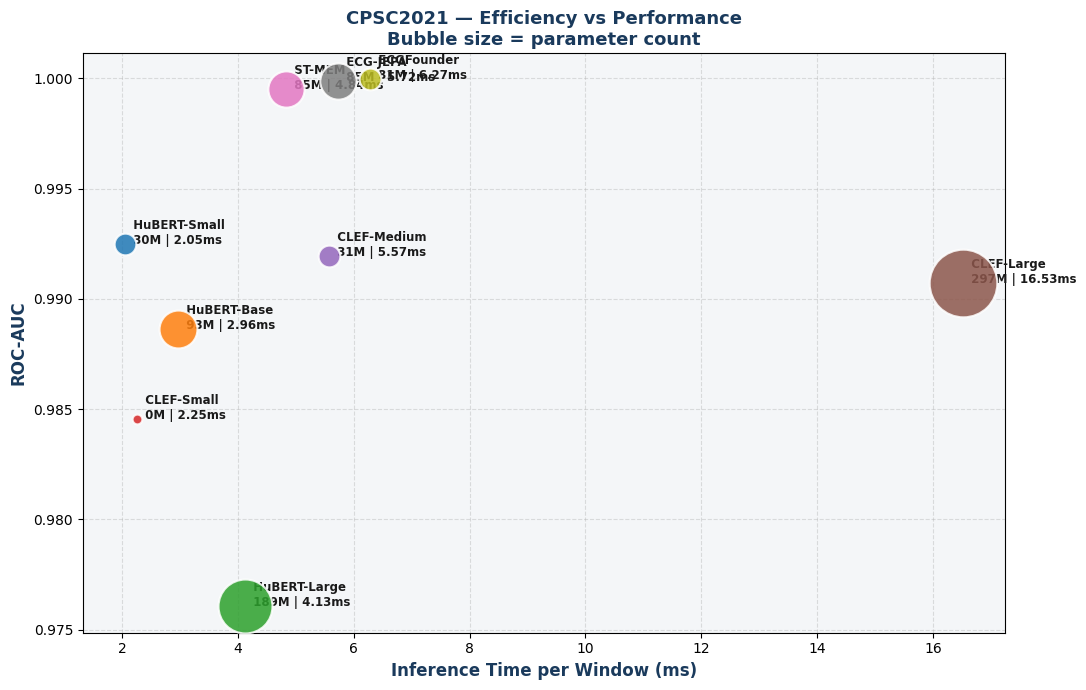

✓ Saved: CPSC2021_efficiency_plot.png

All outputs saved to: /content/drive/MyDrive/ECG project Amirhossein taleshi/CPSC2021_benchmark
Files included in ZIP:
  CLEF-Large_efficiency.csv                                    0.1 KB
  CLEF-Large_predictions.csv                               11792.2 KB
  CLEF-Large_results.csv                                       0.2 KB
  CLEF-Medium_efficiency.csv                                   0.1 KB
  CLEF-Medium_predictions.csv                              11780.0 KB
  CLEF-Medium_results.csv                                      0.2 KB
  CLEF-Small_efficiency.csv                                    0.1 KB
  CLEF-Small_predictions.csv                               11692.7 KB
  CLEF-Small_results.csv                                       0.2 KB
  CPSC2021_comparison_chart.png                              158.7 KB
  CPSC2021_efficiency_plot.png                               147.9 KB
  CPSC2021_summary.csv                                         0.7 KB
  

In [15]:
import matplotlib.pyplot as plt, matplotlib.colors as mcolors
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from PIL import Image

TC = '#1A3A5C'

# ── 1. Summary table ───────────────────────────────────────────────────────────
rows = []
for r in ALL_RESULTS:
    if isinstance(r, dict):
        rows.append({'Model'      : r['model'],
                     'AUC'        : f"{r['auc']:.4f}±{r['auc_std']:.4f}",
                     'F1'         : f"{r['f1']:.4f}±{r['f1_std']:.4f}",
                     'Accuracy'   : f"{r['acc']:.4f}±{r['acc_std']:.4f}",
                     'Sensitivity': f"{r['sens']:.4f}",
                     'Specificity': f"{r['spec']:.4f}",
                     '_auc'       : r['auc']})

df_summary = (pd.DataFrame(rows)
              .sort_values('_auc', ascending=False)
              .drop('_auc', axis=1)
              .reset_index(drop=True))
df_summary.insert(0, 'Rank', range(1, len(df_summary)+1))
df_summary.to_csv(os.path.join(OUT_DIR, f'{DATASET_NAME}_summary.csv'), index=False)
print(df_summary.to_string(index=False))

df_p = (pd.DataFrame([{k:v for k,v in r.items() if k != 'all_preds'}
                       for r in ALL_RESULTS if isinstance(r, dict)])
        .sort_values('auc', ascending=False))

# ── 2. Bar chart ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.patch.set_facecolor('white')
fig.suptitle(f'{DATASET_NAME} — 9 ECG Foundation Models | XGBoost | '
             f'{FS_BASE} Hz | 10s | 5s overlap | GroupKFold',
             fontsize=13, fontweight='bold', color=TC)

for ax, (met, err, lbl) in zip(axes, [('auc','auc_std','ROC-AUC'),
                                        ('f1', 'f1_std', 'F1 Score'),
                                        ('sens', None,   'Sensitivity')]):
    vals = df_p[met].tolist()
    norm   = plt.Normalize(min(vals), max(vals))
    colors = [mcolors.to_hex(plt.cm.RdYlGn(norm(v))) for v in vals]
    ax.set_facecolor('#F4F6F8')
    bars = ax.barh(df_p['model'], vals, color=colors,
                   edgecolor='white', linewidth=0.8, alpha=0.92)
    if err and err in df_p.columns:
        ax.errorbar(vals, df_p['model'], xerr=df_p[err].tolist(),
                    fmt='none', color='#444', capsize=3, lw=1)
    for bar, v in zip(bars, vals):
        ax.text(v+0.003, bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8.5,
                fontweight='bold', color=TC)
    ax.set_xlabel(lbl, fontsize=11, fontweight='bold', color=TC)
    ax.set_xlim(0, 1.12)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.invert_yaxis()

plt.tight_layout()
chart = os.path.join(OUT_DIR, f'{DATASET_NAME}_comparison_chart.png')
plt.savefig(chart, dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); plt.close()
print(f'✓ Saved: {os.path.basename(chart)}')

# ── 3. t-SNE (3×3 grid, one panel per model) ──────────────────────────────────
np.random.seed(42)
n_each  = min(1500, int((labels==1).sum()), int((labels==0).sum()))
sub_idx = np.concatenate([
    np.random.choice(np.where(labels==1)[0], n_each, replace=False),
    np.random.choice(np.where(labels==0)[0], n_each, replace=False),
])
np.random.shuffle(sub_idx)
sub_lbl = labels[sub_idx]

tsne_imgs = []
for r in ALL_RESULTS:
    if not isinstance(r, dict): continue
    name = r['model']
    npy  = os.path.join(OUT_DIR, f'{name}_embs.npy')
    if not os.path.exists(npy):
        print(f'  Skip t-SNE {name} — no embedding cache'); continue

    print(f'  t-SNE: {name} ...', end=' ', flush=True)
    emb  = StandardScaler().fit_transform(np.load(npy)[sub_idx])
    proj = TSNE(n_components=2, perplexity=40, n_iter=1000,
                random_state=42, n_jobs=-1).fit_transform(emb)

    fig, ax = plt.subplots(figsize=(5.5, 5))
    fig.patch.set_facecolor('white'); ax.set_facecolor('#F4F6F8')
    for lv, clr, ln in [(0,'#2980B9','Normal'), (1,'#E74C3C','AF')]:
        m = sub_lbl == lv
        ax.scatter(proj[m,0], proj[m,1], c=clr, label=ln,
                   s=5, alpha=0.5, linewidths=0)
    ax.set_title(f'{name}\nAUC={r["auc"]:.4f}  F1={r["f1"]:.4f}',
                 fontsize=10, fontweight='bold', color=TC)
    ax.legend(fontsize=8, markerscale=3)
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    tmp = os.path.join(OUT_DIR, f'_tsne_{name}.png')
    plt.savefig(tmp, dpi=120, bbox_inches='tight', facecolor='white')
    plt.close()
    tsne_imgs.append(tmp)
    del emb, proj; gc.collect()
    print('done')

if len(tsne_imgs) >= 2:
    imgs  = [Image.open(p) for p in tsne_imgs]
    W, H  = imgs[0].size
    nc    = 3; nr = (len(imgs) + 2) // 3
    grid  = Image.new('RGB', (W*nc, H*nr), (255, 255, 255))
    for i, im in enumerate(imgs):
        grid.paste(im, ((i % nc)*W, (i // nc)*H))
    tsne_path = os.path.join(OUT_DIR, f'{DATASET_NAME}_tsne_all_models.png')
    grid.save(tsne_path)
    print(f'✓ Saved: {os.path.basename(tsne_path)}')
    for p in tsne_imgs: os.remove(p)

# ── 4. Efficiency scatter ──────────────────────────────────────────────────────
if ALL_EFFICIENCY:
    auc_map = {r['model']: r['auc'] for r in ALL_RESULTS if isinstance(r, dict)}
    df_e    = pd.DataFrame(ALL_EFFICIENCY)
    df_e['auc'] = df_e['model'].map(auc_map)

    fig, ax = plt.subplots(figsize=(11, 7))
    fig.patch.set_facecolor('white'); ax.set_facecolor('#F4F6F8')
    for _, row in df_e.iterrows():
        ax.scatter(row['ms_per_window'], row['auc'],
                   s=max(row['params_M']*8, 50),
                   alpha=0.85, edgecolors='white', linewidths=1.5, zorder=5)
        ax.annotate(f"  {row['model']}\n"
                    f"  {row['params_M']:.0f}M | {row['ms_per_window']:.2f}ms",
                    (row['ms_per_window'], row['auc']),
                    fontsize=8.5, fontweight='bold', color='#1A1A1A')
    ax.set_xlabel('Inference Time per Window (ms)', fontsize=12,
                  fontweight='bold', color=TC)
    ax.set_ylabel('ROC-AUC', fontsize=12, fontweight='bold', color=TC)
    ax.set_title(f'{DATASET_NAME} — Efficiency vs Performance\n'
                 'Bubble size = parameter count',
                 fontsize=13, fontweight='bold', color=TC)
    ax.grid(linestyle='--', alpha=0.4)
    plt.tight_layout()
    eff_plot = os.path.join(OUT_DIR, f'{DATASET_NAME}_efficiency_plot.png')
    plt.savefig(eff_plot, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show(); plt.close()
    print(f'✓ Saved: {os.path.basename(eff_plot)}')

# ── 5. ZIP everything ─────────────────────────────────────────────────────────
import zipfile
zip_path = os.path.join(OUT_DIR, f'{DATASET_NAME}_full_results.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in sorted(os.listdir(OUT_DIR)):
        if fname.endswith(('.csv', '.png')):
            zf.write(os.path.join(OUT_DIR, fname), fname)

print(f'\n{"="*55}')
print(f'All outputs saved to: {OUT_DIR}')
print(f'Files included in ZIP:')
with zipfile.ZipFile(zip_path) as zf:
    for info in zf.infolist():
        print(f'  {info.filename:<55} {info.file_size/1024:>8.1f} KB')